# Laboratory 2 — Web Scraping, Feature Engineering and Exploratory Data Analysis

**Course:** Introduction to Artificial Intelligence (AI–101L) · **Instructor:** Dr. Muhammad Awais
**Duration:** 3 hours · **Block:** Phase A — Environment and Data · **Mapped CLO:** CLO–2

---

## Learning Objectives

On completion of this laboratory you will be able to:

1. Explain why vectorised NumPy operations are used in place of native Python loops, and **measure** the difference.
2. Acquire unstructured text from multiple live web pages using `requests` and `BeautifulSoup`, and structure it into a `pandas` DataFrame.
3. Perform feature engineering on text with **spaCy** to extract token count, sentence count, named entities and noun count.
4. Compute sentiment **polarity** and **subjectivity** with **TextBlob**.
5. Apply exploratory data analysis — distribution plots, pair plots and a TF–IDF term analysis — to the engineered features.

## Background

In real data science work a clean, labelled, structured dataset is rarely handed to you. **It has
to be built.** This laboratory implements the first complete pipeline of the course:

```
Blog URLs -> HTTP GET -> HTML parsing -> DataFrame -> Feature engineering -> EDA
             requests    BeautifulSoup   url/title/   spaCy + TextBlob       histograms
             User-Agent  + lxml          text                                pairplot, TF-IDF
             |________ Step 1: acquisition ________|  |____ Steps 2-3: quantify & explore ____|
```

> **Instructor note.** Live websites change. If a selector stops matching, that *is* the lesson —
> Exercise 1 asks students to diagnose exactly this. Have a cached copy of `articles.csv` ready
> so that Sections 4–5 can proceed even if the network is unavailable.

### Justification of libraries and tools

| Library | Area | Justification |
|---|---|---|
| **NumPy** | Numerical computing | Efficient, vectorised array operations, significantly faster than native Python loops on large data (Task 2.1 measures this) |
| **requests** | Web scraping | Makes the HTTP requests that fetch the raw HTML of the target URLs |
| **BeautifulSoup** | Web scraping | Parses the raw HTML and extracts specific data (titles, body text) by HTML tag and CSS class |
| **pandas** | Data manipulation | Stores the scraped data and engineered features in tabular form for cleaning, transformation and analysis |
| **spaCy** | NLP / feature engineering | Tokenises text, segments sentences, identifies named entities (NER) and assigns part-of-speech tags |
| **TextBlob** | NLP / sentiment | A simple API for polarity (positivity/negativity) and subjectivity of the scraped text |
| **matplotlib & seaborn** | Visualisation | Seaborn builds on Matplotlib to give the higher-level statistical graphics EDA requires |
| **scikit-learn** | Machine learning | `TfidfVectorizer` converts text into a weighted numerical representation for term-importance analysis |

---
# Task 2.1 — Setup, and why NumPy exists

Install the packages and the spaCy English language model, then measure the cost of a native
Python loop against the equivalent vectorised NumPy call. **Record both timings in your report.**

In [1]:
# Installation of required libraries (run once per environment)
!pip install requests beautifulsoup4 lxml pandas spacy matplotlib seaborn textblob

# Download the small English language model for spaCy
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta 


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


> ### Troubleshooting: `ForwardRef._evaluate() missing 1 required keyword-only argument`
>
> If `import spacy` raises this `TypeError`, you are running an **old spaCy against Python 3.12**.
> spaCy's schema module still uses the legacy `pydantic.v1` API, which Python 3.12 broke.
>
> Two fixes, in order of preference:
>
> 1. **Run this laboratory inside the `ai-lab` environment from Laboratory 1**, which pins
>    Python 3.11:
>    ```
>    conda activate ai-lab
>    ```
> 2. Or upgrade in place:
>    ```
>    pip install -U "spacy>=3.7.5" "pydantic>=2.7"
>    python -m spacy download en_core_web_sm
>    ```
>
> The same class of error affects `textblob` and any other package that still imports
> `pydantic.v1`. **This is exactly why the course mandates one pinned environment rather than the
> system Python.**

In [2]:
import numpy as np
import time

size = 10_000_000
data = np.random.rand(size)

# --- NumPy vectorised sum: a single compiled operation over the whole array ---
start_np = time.time()
np_sum = np.sum(data)
end_np = time.time()

# --- Manual Python loop: ten million interpreted iterations ------------------
start_py = time.time()
manual_sum = 0
for val in data:
    manual_sum += val
end_py = time.time()

print(f"NumPy Sum : {np_sum:.2f} | Time: {end_np - start_np:.5f} sec")
print(f"Manual Sum: {manual_sum:.2f} | Time: {end_py - start_py:.5f} sec")
print()
print(f"NumPy is {(end_py - start_py) / (end_np - start_np):.0f}x faster on this machine.")

NumPy Sum : 4999773.75 | Time: 0.01371 sec
Manual Sum: 4999773.75 | Time: 4.71051 sec

NumPy is 344x faster on this machine.


> ### Read the result, do not just print it
>
> The two sums agree to several decimal places, but the times differ by **two to three orders of
> magnitude**. Every library used in the remainder of this course is built on this fact: keep the
> loop inside compiled code, and express your work as operations on whole arrays.

---
# Task 2.2 — Web scraping and data acquisition

Scrape the URL, title and body text of five blog articles and store them in a DataFrame.

**Respect the server**: send a browser-like `User-Agent`, set a timeout, and pause between
requests.

| Code | Explanation |
|---|---|
| `headers = {...}` | Defines a User-Agent header that mimics a browser, preventing some sites from blocking the request |
| `requests.get(url, ...)` | Executes the HTTP GET request for the current URL |
| `BeautifulSoup(res.content, 'lxml')` | Parses the raw HTML with the fast `lxml` parser |
| `soup.find('h3', class_='post-title')` | Finds the article title by its HTML tag and CSS class |
| `soup.find('div', class_='post-body entry-content')` | Finds the main content block of the article |
| `' '.join(p.get_text(strip=True) ...)` | Extracts the text of every `<p>` tag inside the content block and joins it |
| `pd.DataFrame(articles)` | Creates the final DataFrame of scraped records |

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

urls = [
    'https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html',
    'https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html',
    'https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html',
    'https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html',
    'https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html'
]

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
articles = []

for url in urls:
    try:
        # Fetch the page content
        res = requests.get(url, headers=headers, timeout=10)
        res.raise_for_status()
        soup = BeautifulSoup(res.content, 'lxml')

        # Extract Title
        title = soup.find('h3', class_='post-title')
        title = title.get_text(strip=True) if title else soup.title.get_text(strip=True)

        # Extract Body Text
        content_div = soup.find('div', class_='post-body entry-content')
        if not content_div:
            print(f"[SKIP] No content block found: {url}")
            continue

        paragraphs = content_div.find_all('p')
        text = ' '.join(p.get_text(strip=True) for p in paragraphs)

        # Skip short articles for quality control
        if len(text) > 100:
            articles.append({'url': url, 'title': title, 'text': text})
        else:
            print(f"[SKIP] Too short: {url}")

        time.sleep(1)   # Be polite to the server
    except Exception as e:
        print(f"[ERROR] {url} -> {e}")

df = pd.DataFrame(articles)
print(f"\nScraped {len(df)} of {len(urls)} articles.")
df.head()

[SKIP] Too short: https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html



Scraped 4 of 5 articles.


,url,title,text
0,https://techncruncher.blogspot.com/2025/01/top...,Top 10 AI Tools That Will Transform Your Conte...,Looking to level up your content creation gam...
1,https://techncruncher.blogspot.com/2023/12/lim...,"LimeWire AI Studio Review 2023: Details, Prici...",In the rapidly advancing landscape of AI tech...
2,https://techncruncher.blogspot.com/2023/01/top...,Top 10 AI Tools in 2023 That Will Make Your Li...,"In this article, we explore the top 10 AI too..."
3,https://techncruncher.blogspot.com/2022/11/top...,Top 10 AI Content Generator & Writer Tools in ...,There are a number of different AI content ...


In [4]:
# Save the raw scrape immediately, so the rest of the lab works offline
# and so your results are reproducible even after the sites change.
if not df.empty:
    df.to_csv("articles_raw.csv", index=False)
    print("Saved articles_raw.csv")
else:
    # Fallback: load a previously saved scrape
    df = pd.read_csv("articles_raw.csv")
    print("Network scrape empty -- loaded the cached articles_raw.csv instead.")

print(df.shape)

Saved articles_raw.csv
(4, 3)


---
# Task 2.3 — Linguistic feature engineering with spaCy

Feature engineering **quantifies the qualitative text**. The `extract_features` function derives
four metrics per article:

| Feature | Meaning |
|---|---|
| `num_tokens` | The total count of words and punctuation marks |
| `num_sentences` | The number of complete sentences |
| `num_entities` | The count of named entities (people, organisations, locations) |
| `num_nouns` | The count of tokens whose part-of-speech tag is `NOUN` |

In [5]:
import spacy
import pandas as pd

# Loads the trained spaCy English model: tokenizer, POS tagger and NER
nlp = spacy.load("en_core_web_sm")

def extract_features(text):
    """Process text with spaCy and extract four linguistic features."""
    doc = nlp(text)
    return pd.Series({
        'num_tokens':    len(doc),                                   # tokens
        'num_sentences': len(list(doc.sents)),                       # sentences
        'num_entities':  len(doc.ents),                              # named entities
        'num_nouns':     len([t for t in doc if t.pos_ == 'NOUN'])   # nouns
    })

if not df.empty:
    features = df['text'].apply(extract_features)
    df = pd.concat([df, features], axis=1)

    # A simple non-spaCy feature for comparison
    df['title_length'] = df['title'].apply(len)

    print("Features extracted successfully.")
    display(df[['title', 'num_tokens', 'num_sentences', 'num_entities', 'num_nouns']].head())
else:
    print("No articles found for feature extraction.")

Features extracted successfully.


,title,num_tokens,num_sentences,num_entities,num_nouns
0,Top 10 AI Tools That Will Transform Your Conte...,1188,47,24,321
1,"LimeWire AI Studio Review 2023: Details, Prici...",1723,65,103,420
2,Top 10 AI Tools in 2023 That Will Make Your Li...,1480,52,39,331
3,Top 10 AI Content Generator & Writer Tools in ...,1319,63,89,271


In [6]:
# Inspect WHAT spaCy actually found, not just how many.
# Reading the entities is how you learn whether the feature is meaningful.

doc = nlp(df['text'].iloc[0][:1500])

print("First 15 named entities in article 1:\n")
for ent in list(doc.ents)[:15]:
    print(f"  {ent.text:<35} {ent.label_:<12} ({spacy.explain(ent.label_)})")

First 15 named entities in article 1:

  2025                                DATE         (Absolute or relative dates or periods)
  AI                                  GPE          (Countries, cities, states)
  10                                  CARDINAL     (Numerals that do not fall under another type)
  AI                                  GPE          (Countries, cities, states)
  2025                                DATE         (Absolute or relative dates or periods)
  AI                                  GPE          (Countries, cities, states)
  Dive Into the Top 10                WORK_OF_ART  (Titles of books, songs, etc.)
  2025                                DATE         (Absolute or relative dates or periods)
  Magic Studio                        PERSON       (People, including fictional)
  AI                                  ORG          (Companies, agencies, institutions, etc.)


## Sentiment features with TextBlob

TextBlob provides a quick way to calculate two independent scores:

- **Polarity** runs from $-1.0$ (strongly negative) through $0.0$ (neutral) to $+1.0$ (strongly positive).
- **Subjectivity** runs from $0.0$ (a purely objective statement of fact) to $1.0$ (a purely personal opinion).

In [7]:
from textblob import TextBlob

def get_sentiment(text):
    """Polarity in [-1, 1]; subjectivity in [0, 1]."""
    blob = TextBlob(text)
    return pd.Series({
        'sentiment_polarity':     blob.sentiment.polarity,
        'sentiment_subjectivity': blob.sentiment.subjectivity
    })

if not df.empty:
    sentiment_features = df['text'].apply(get_sentiment)
    df = pd.concat([df, sentiment_features], axis=1)

    print("Sentiment features extracted successfully.\n")
    display(df[['title', 'sentiment_polarity', 'sentiment_subjectivity']])

Sentiment features extracted successfully.



,title,sentiment_polarity,sentiment_subjectivity
0,Top 10 AI Tools That Will Transform Your Conte...,0.229493,0.583603
1,"LimeWire AI Studio Review 2023: Details, Prici...",0.219387,0.573587
2,Top 10 AI Tools in 2023 That Will Make Your Li...,0.197417,0.436441
3,Top 10 AI Content Generator & Writer Tools in ...,0.214853,0.564907


> ### Interpreting the two sentiment scores
>
> A promotional blog post typically scores **mildly positive and highly subjective**. Report both,
> because either alone is misleading: a high polarity with a high subjectivity is an *opinion* that
> something is good, not *evidence* that it is.

In [8]:
# Persist the fully engineered table -- this is the Lab 02 deliverable.
df.to_csv("articles.csv", index=False)
print("Saved articles.csv with", df.shape[1], "columns:")
print(list(df.columns))

Saved articles.csv with 10 columns:
['url', 'title', 'text', 'num_tokens', 'num_sentences', 'num_entities', 'num_nouns', 'title_length', 'sentiment_polarity', 'sentiment_subjectivity']


---
# Task 2.4 — Exploratory Data Analysis

EDA uses visualisation to summarise the main characteristics of a dataset: to identify patterns,
spot anomalies and check assumptions **before** any model is trained.

## A. Distributions of individual features

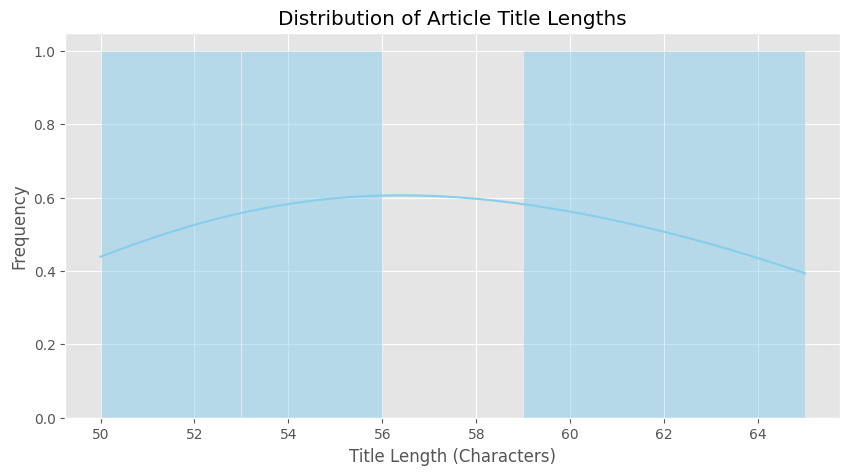

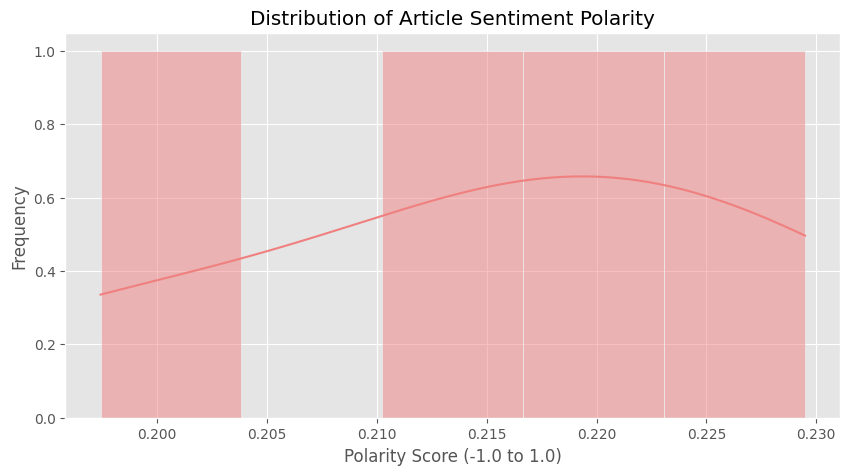

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# 1. Title Length Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['title_length'], kde=True, bins=5, color='skyblue')
plt.title('Distribution of Article Title Lengths')
plt.xlabel('Title Length (Characters)')
plt.ylabel('Frequency')
plt.show()

# 2. Sentiment Polarity Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['sentiment_polarity'], kde=True, bins=5, color='lightcoral')
plt.title('Distribution of Article Sentiment Polarity')
plt.xlabel('Polarity Score (-1.0 to 1.0)')
plt.ylabel('Frequency')
plt.show()

## B. Pairwise relationships between the derived numeric features

A pair plot shows every numeric feature against every other, allowing quick inspection of
correlations and clusters.

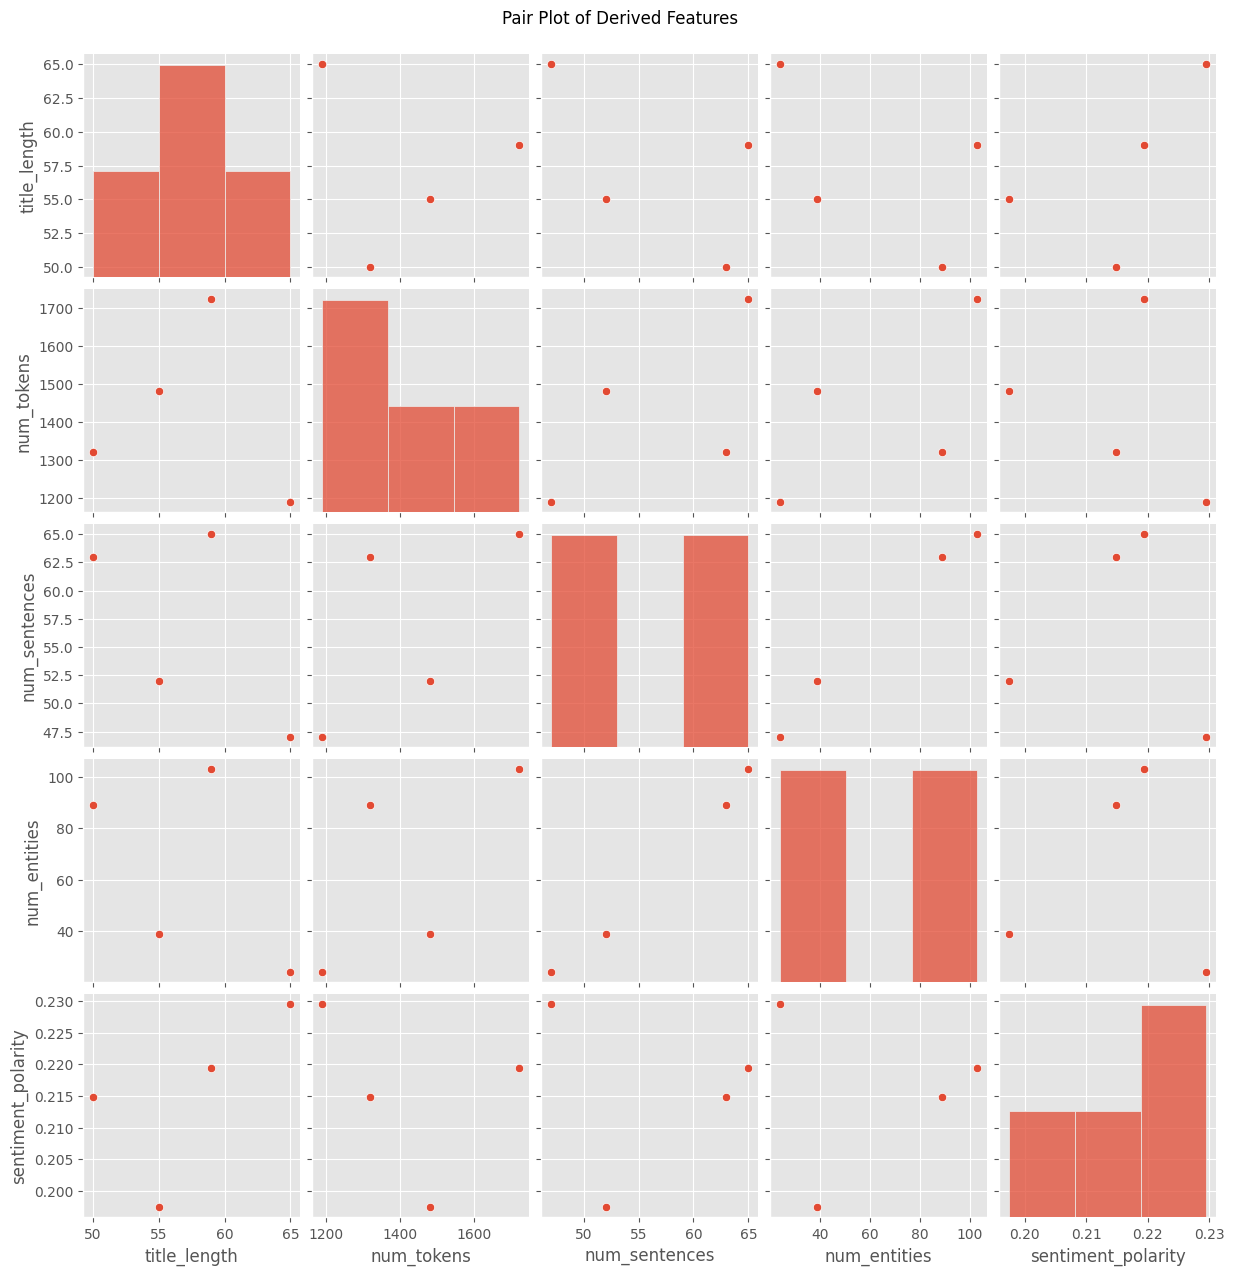

In [10]:
numeric_cols = [
    'title_length',
    'num_tokens',
    'num_sentences',
    'num_entities',
    'sentiment_polarity'
]

sns.pairplot(df[numeric_cols])
plt.suptitle('Pair Plot of Derived Features', y=1.02)
plt.show()

In [11]:
# The same information as numbers. With five articles this is indicative only.
print("Correlation matrix:\n")
display(df[numeric_cols].corr().round(2))

Correlation matrix:



,title_length,num_tokens,num_sentences,num_entities,sentiment_polarity
title_length,1.00,-0.15,-0.58,-0.50,0.63
num_tokens,-0.15,1.00,0.64,0.65,-0.33
num_sentences,-0.58,0.64,1.00,1.00,-0.06
num_entities,-0.50,0.65,1.00,1.00,0.02
sentiment_polarity,0.63,-0.33,-0.06,0.02,1.00


## C. Advanced text feature — TF–IDF analysis

**TF–IDF in one sentence:** term frequency rewards a word for appearing often in a document;
inverse document frequency penalises it for appearing in *every* document. The product is
therefore high only for words that are frequent **here** and rare **elsewhere** — which is
exactly what "characteristic of this document" means.

| Code | Explanation |
|---|---|
| `TfidfVectorizer(...)` | `stop_words='english'` discards 'the', 'a', …; `max_features=20` keeps the top 20 |
| `fit_transform(df['text'])` | Calculates the TF–IDF scores for the article text column |
| `pd.DataFrame(X.toarray(), ...)` | Converts the sparse matrix into a readable DataFrame |
| `tfidf_df.sum().sort_values(...)` | Sums scores across all documents to rank global importance |

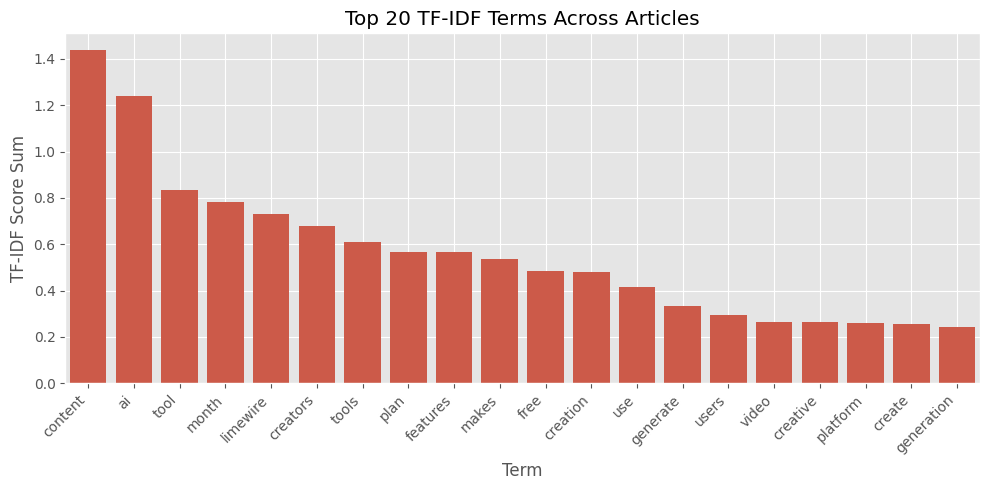

Sparse matrix shape (documents x terms): (4, 20)


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# stop_words='english' discards 'the', 'a', ...; max_features keeps the top 20
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['text'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Sum each term's score across all documents to rank global importance
tfidf_sums = tfidf_df.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=tfidf_sums.index, y=tfidf_sums.values)
plt.title("Top 20 TF-IDF Terms Across Articles")
plt.ylabel("TF-IDF Score Sum")
plt.xlabel("Term")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Sparse matrix shape (documents x terms):", X.shape)

---
# In-Lab Exercises

Complete all four during the session.

**Exercise 1.** Add two URLs of your own choosing to the list. Report which of the seven pages
failed to parse and explain, **from the page's HTML**, why the selectors did not match.

**Exercise 2.** Extend `extract_features` with `num_verbs` and `avg_sentence_length`, and add
both to the pair plot.

**Exercise 3.** The polarity histogram is computed over five articles. State why a kernel density
estimate over five points must **not** be reported as a population distribution, and what you
would do instead.

**Exercise 4.** Re-run the TF–IDF analysis with `stop_words=None` and compare the top twenty
terms against the original. Explain the difference.

,title,num_tokens,num_sentences,num_entities,num_nouns,num_verbs,avg_sentence_length
0,Top 10 AI Tools That Will Transform Your Conte...,1188.0,47.0,24.0,321.0,150.0,25.276596
1,"LimeWire AI Studio Review 2023: Details, Prici...",1723.0,65.0,103.0,420.0,200.0,26.507692
2,Top 10 AI Tools in 2023 That Will Make Your Li...,1480.0,52.0,39.0,331.0,166.0,28.461538
3,Top 10 AI Content Generator & Writer Tools in ...,1319.0,63.0,89.0,271.0,140.0,20.936508


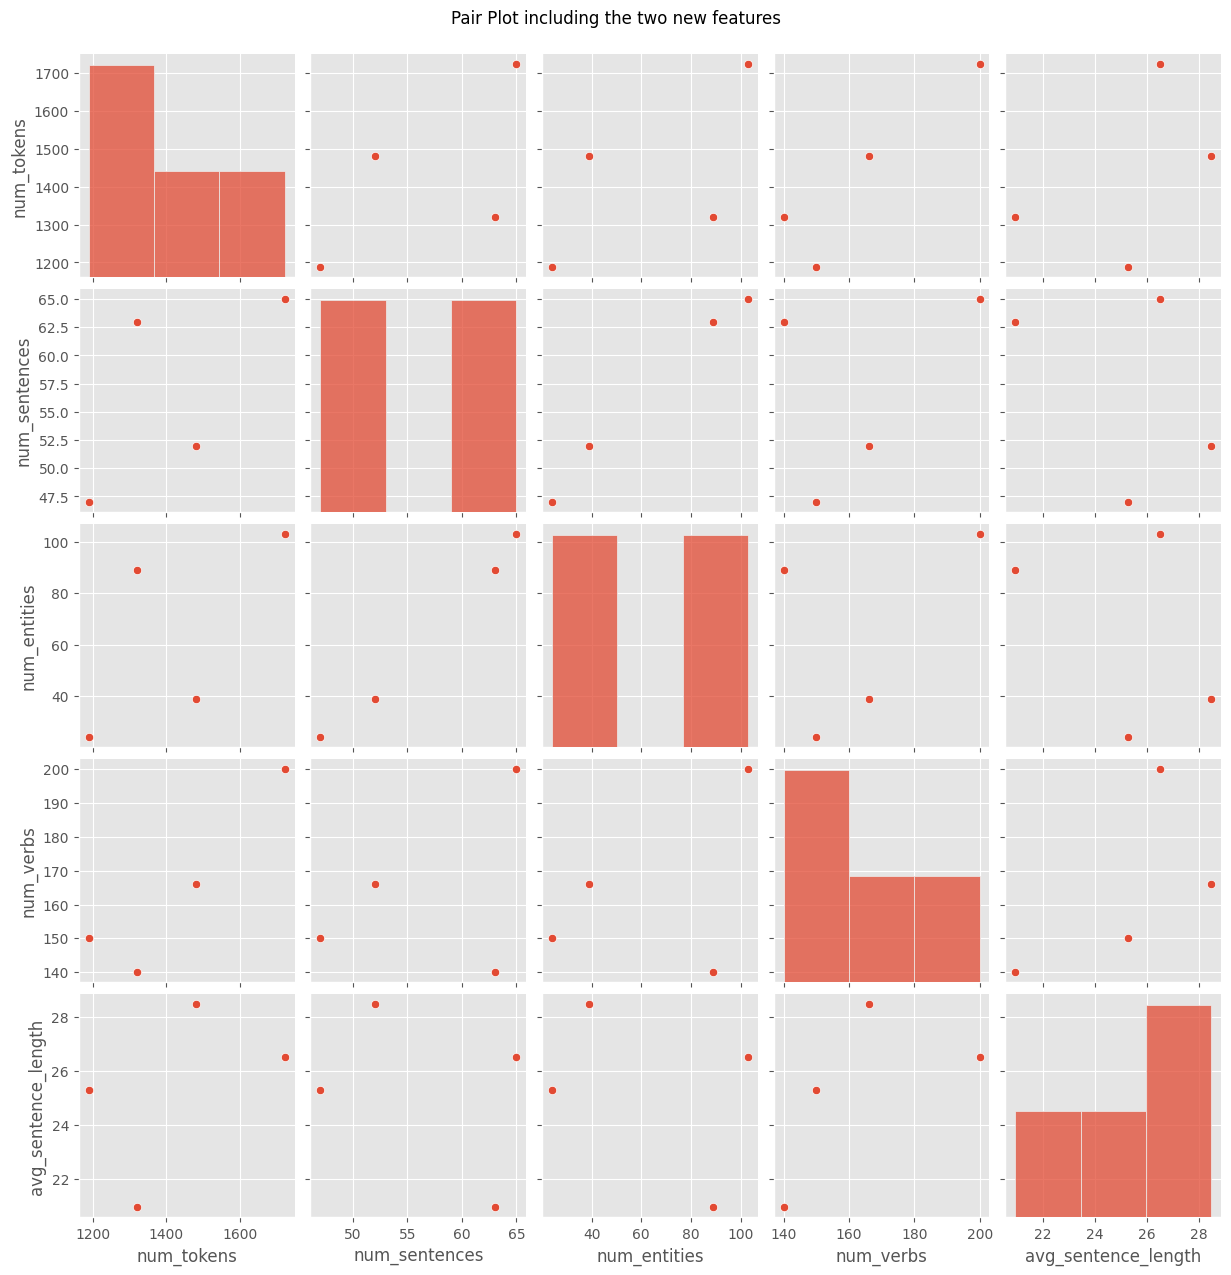

In [13]:
# --- Exercise 2: extended feature extraction -----------------------------

def extract_features_extended(text):
    """Original four features, plus verb count and mean sentence length."""
    doc = nlp(text)
    sentences = list(doc.sents)
    return pd.Series({
        'num_tokens':          len(doc),
        'num_sentences':       len(sentences),
        'num_entities':        len(doc.ents),
        'num_nouns':           len([t for t in doc if t.pos_ == 'NOUN']),
        'num_verbs':           len([t for t in doc if t.pos_ == 'VERB']),
        'avg_sentence_length': (len(doc) / len(sentences)) if sentences else 0.0,
    })


extended = df['text'].apply(extract_features_extended)
df_ext = pd.concat([df[['title']], extended], axis=1)
display(df_ext)

sns.pairplot(df_ext[['num_tokens', 'num_sentences', 'num_entities',
                     'num_verbs', 'avg_sentence_length']])
plt.suptitle('Pair Plot including the two new features', y=1.02)
plt.show()

In [14]:
# --- Exercise 4: TF-IDF with and without stop-word removal ---------------

vec_stop = TfidfVectorizer(stop_words='english', max_features=20)
vec_none = TfidfVectorizer(stop_words=None,      max_features=20)

top_stop = (pd.DataFrame(vec_stop.fit_transform(df['text']).toarray(),
                         columns=vec_stop.get_feature_names_out())
              .sum().sort_values(ascending=False))
top_none = (pd.DataFrame(vec_none.fit_transform(df['text']).toarray(),
                         columns=vec_none.get_feature_names_out())
              .sum().sort_values(ascending=False))

comparison = pd.DataFrame({
    "with stop_words='english'": top_stop.index,
    "with stop_words=None":      top_none.index,
})
display(comparison)

print("\nTerms that appear ONLY when stop words are kept:")
print(sorted(set(top_none.index) - set(top_stop.index)))

,with stop_words='english',with stop_words=None
0,content,and
1,ai,the
2,tool,to
3,month,for
4,limewire,content
5,creators,it
6,tools,of
7,plan,ai
8,features,month
9,makes,you



Terms that appear ONLY when stop words are kept:
['and', 'as', 'can', 'for', 'in', 'is', 'it', 'of', 'that', 'the', 'to', 'with', 'you', 'your']


**Your answer to Exercise 3** (why a KDE over five points is not a population distribution):

*(double-click and write your answer here)*

---

---
# Home Assignment

Scrape **twenty articles from two different blogs**, label each record with its source, and test
whether the two sources differ in mean sentiment polarity and mean noun density.

Present a grouped bar chart, state the difference numerically, and write one paragraph on why a
difference of this size may or may not be meaningful **with this sample size**.

Commit the notebook, the scraped CSV and the report.

In [15]:
# --- Home assignment scaffold --------------------------------------------
# Fill in your own URL lists and run.

SOURCE_A = {
    "name": "blog-a",
    "urls": [
        # ... ten article URLs ...
    ],
    "title_selector":   ("h3", "post-title"),
    "content_selector": ("div", "post-body entry-content"),
}

SOURCE_B = {
    "name": "blog-b",
    "urls": [
        # ... ten article URLs ...
    ],
    "title_selector":   ("h1", None),
    "content_selector": ("div", None),
}


def scrape_source(source):
    """Scrape one source and return a labelled DataFrame."""
    rows = []
    for url in source["urls"]:
        try:
            res = requests.get(url, headers=headers, timeout=10)
            res.raise_for_status()
            soup = BeautifulSoup(res.content, "lxml")

            tag, cls = source["title_selector"]
            t = soup.find(tag, class_=cls) if cls else soup.find(tag)
            title = t.get_text(strip=True) if t else soup.title.get_text(strip=True)

            tag, cls = source["content_selector"]
            block = soup.find(tag, class_=cls) if cls else soup.find(tag)
            if not block:
                continue
            text = " ".join(p.get_text(strip=True) for p in block.find_all("p"))

            if len(text) > 100:
                rows.append({"source": source["name"], "url": url,
                             "title": title, "text": text})
            time.sleep(1)
        except Exception as e:
            print(f"[ERROR] {url} -> {e}")
    return pd.DataFrame(rows)


# corpus = pd.concat([scrape_source(SOURCE_A), scrape_source(SOURCE_B)], ignore_index=True)
# corpus.to_csv("two_source_corpus.csv", index=False)
print("Fill in SOURCE_A and SOURCE_B, then uncomment the last two lines.")

Fill in SOURCE_A and SOURCE_B, then uncomment the last two lines.


---
# Deliverables

| File | Contents |
|---|---|
| `lab02/scraping_eda.ipynb` | This notebook, executed, with all outputs visible |
| `lab02/articles.csv` | The scraped corpus with all engineered features |
| `lab02/figures/*.png` | The four figures exported as PNG |
| `lab02/report.md` | The NumPy timing comparison, the EDA findings and the TF–IDF interpretation |

## Assessment Rubric

| Criterion | Weight | Excellent performance |
|---|---|---|
| Correctness of implementation | 35 % | Scraper handles failures gracefully; features computed correctly |
| Methodological soundness | 25 % | Server treated politely; sample-size limits acknowledged |
| Analysis and interpretation | 20 % | Figures are *read*, not merely produced |
| Code quality and reproducibility | 10 % | Raw scrape cached; functions reusable |
| Report and demonstration | 10 % | Clear written report and working demonstration |

---

**Next laboratory:** Lab 03 — Transforming Textual and Image Data into a Machine-Understandable Format.